In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("uber.csv")

# Display basic structure
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (200000, 9)

First 5 Rows:


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5



Data Types:
Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


In [ ]:
# Make copy to avoid modifying original dataset
clean_df = df.copy()

# Convert datetime column
clean_df['pickup_datetime'] = pd.to_datetime(
    clean_df['pickup_datetime'],
    errors='coerce'
)

# Remove rows where datetime conversion failed
clean_df.dropna(subset=['pickup_datetime'], inplace=True)

# Remove missing values from key numeric fields
clean_df.dropna(inplace=True)

# Remove invalid fare values
clean_df = clean_df[clean_df['fare_amount'] > 0]

# Passenger count restriction (1–6 realistic range)
clean_df = clean_df[
    (clean_df['passenger_count'] >= 1) &
    (clean_df['passenger_count'] <= 6)
]

# Valid geographic coordinate filtering
clean_df = clean_df[
    (clean_df['pickup_latitude'].between(-90, 90)) &
    (clean_df['dropoff_latitude'].between(-90, 90)) &
    (clean_df['pickup_longitude'].between(-180, 180)) &
    (clean_df['dropoff_longitude'].between(-180, 180))
]

# Remove duplicate records
clean_df.drop_duplicates(inplace=True)

print("Cleaning Completed")
print("Final Dataset Shape:", clean_df.shape)

Cleaning Completed
Final Dataset Shape: (199256, 9)


In [ ]:
print("===== DATA CLEANING SUMMARY =====")

print("Original Records:", len(df))
print("Cleaned Records:", len(clean_df))
print("Records Removed:", len(df) - len(clean_df))

print("\nMissing Values After Cleaning:")
print(clean_df.isnull().sum())

print("\nFare Statistics:")
print(clean_df['fare_amount'].describe())

print("\nPassenger Count Distribution:")
print(clean_df['passenger_count'].value_counts().sort_index())

===== DATA CLEANING SUMMARY =====
Original Records: 200000
Cleaned Records: 199256
Records Removed: 744

Missing Values After Cleaning:
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

Fare Statistics:
count    199256.000000
mean         11.369376
std           9.905986
min           0.010000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

Passenger Count Distribution:
passenger_count
1    138405
2     29423
3      8878
4      4275
5     14004
6      4271
Name: count, dtype: int64


feature engineering

In [ ]:
import numpy as np

df_fe = clean_df.copy()

# -----------------------------
# 1. Time-based Features
# -----------------------------

df_fe['hour'] = df_fe['pickup_datetime'].dt.hour
df_fe['day'] = df_fe['pickup_datetime'].dt.day
df_fe['month'] = df_fe['pickup_datetime'].dt.month
df_fe['weekday'] = df_fe['pickup_datetime'].dt.weekday

# Peak hour indicator (Commuting peaks)
df_fe['peak_hour'] = df_fe['hour'].apply(
    lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 21) else 0
)

# -----------------------------
# 2. Distance Feature (Haversine Formula)
# -----------------------------

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians,
                                 [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_fe['distance_km'] = haversine(
    df_fe['pickup_latitude'],
    df_fe['pickup_longitude'],
    df_fe['dropoff_latitude'],
    df_fe['dropoff_longitude']
)

# Remove extreme distance outliers
df_fe = df_fe[df_fe['distance_km'] < df_fe['distance_km'].quantile(0.99)]

print("Feature Engineering Completed")
print("Final Feature Dataset Shape:", df_fe.shape)

# Update working dataset
clean_df = df_fe.copy()

Feature Engineering Completed
Final Feature Dataset Shape: (197263, 15)


UNIVARIATE ANALYSIS

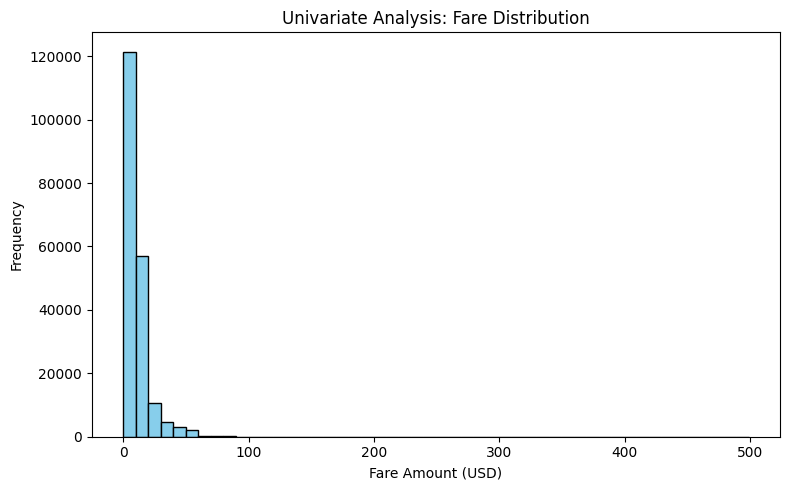

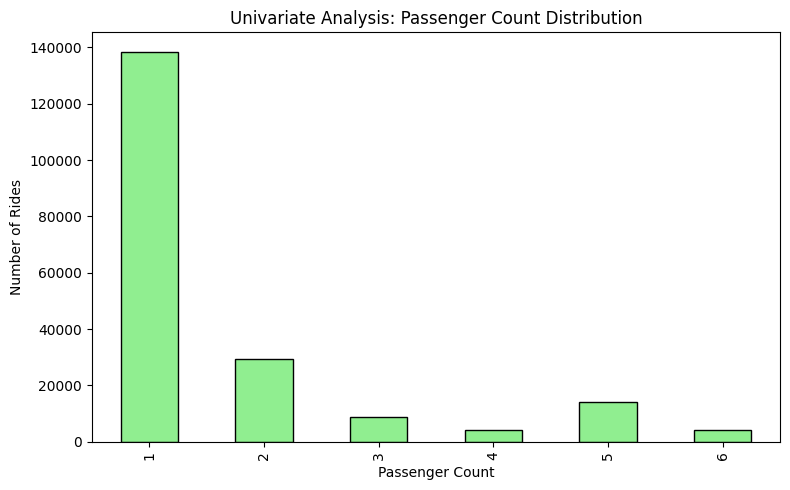

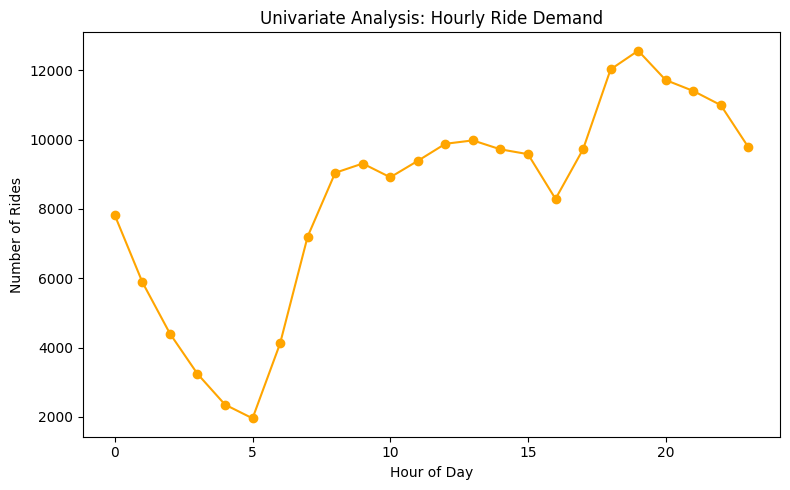

In [ ]:
import matplotlib.pyplot as plt

# Ensure hour column exists for time-based analysis
clean_df['hour'] = clean_df['pickup_datetime'].dt.hour

# 1️⃣ Fare Distribution
plt.figure(figsize=(8,5))
plt.hist(clean_df['fare_amount'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Fare Amount (USD)")
plt.ylabel("Frequency")
plt.title("Univariate Analysis: Fare Distribution")
plt.tight_layout()
plt.show()

# 2️⃣ Passenger Count Distribution
plt.figure(figsize=(8,5))
clean_df['passenger_count'].value_counts().sort_index().plot(
    kind='bar', color='lightgreen', edgecolor='black',
    xlabel="Passenger Count", ylabel="Number of Rides",
    title="Univariate Analysis: Passenger Count Distribution"
)
plt.tight_layout()
plt.show()

# 3️⃣ Hourly Ride Demand
plt.figure(figsize=(8,5))
clean_df['hour'].value_counts().sort_index().plot(
    kind='line', marker='o', color='orange',
    xlabel="Hour of Day", ylabel="Number of Rides",
    title="Univariate Analysis: Hourly Ride Demand"
)
plt.tight_layout()
plt.show()

BIVARIATE

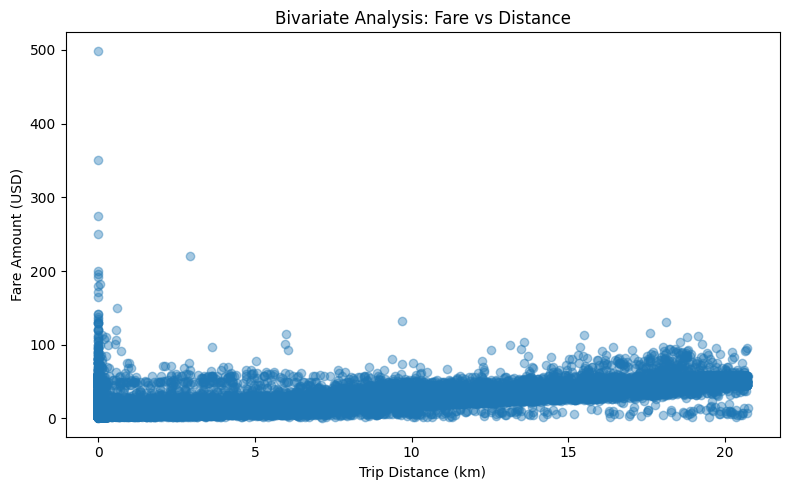

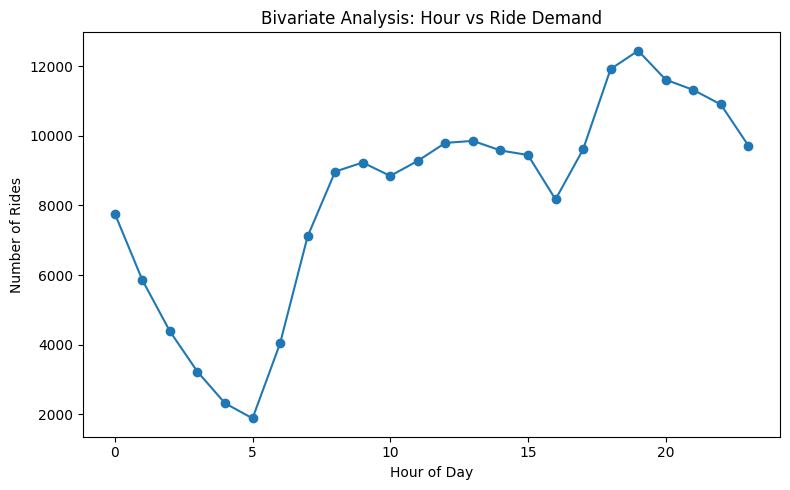

<Figure size 800x500 with 0 Axes>

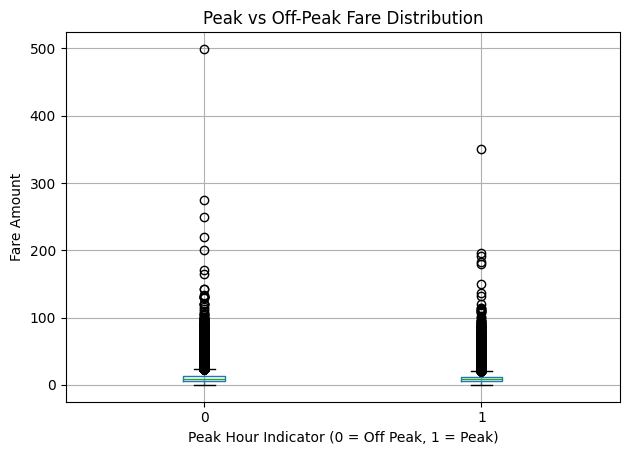

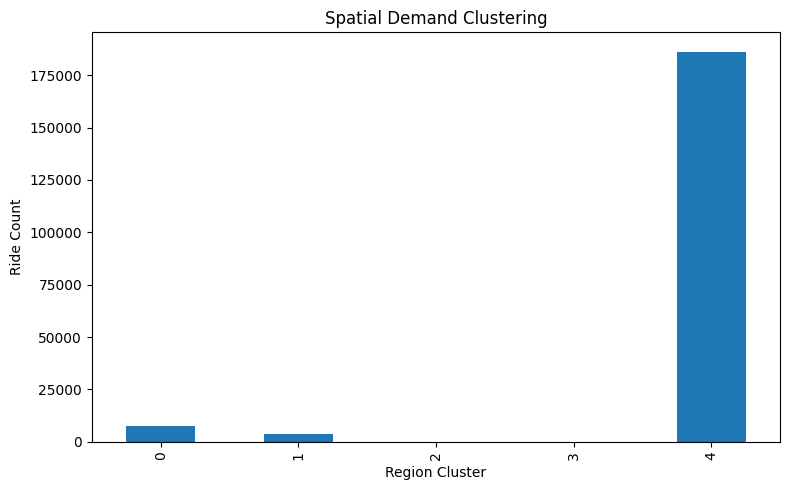

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_bi = clean_df.copy()

# Ensure distance feature exists
if 'distance_km' not in df_bi.columns:
    print("Distance feature missing. Run feature engineering cell first.")

# -----------------------------
# Fare vs Distance Relationship
# -----------------------------

plt.figure(figsize=(8,5))
plt.scatter(df_bi['distance_km'], df_bi['fare_amount'], alpha=0.4)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount (USD)")
plt.title("Bivariate Analysis: Fare vs Distance")
plt.tight_layout()
plt.show()

# -----------------------------
# Hour vs Ride Demand Pattern
# -----------------------------

df_bi['hour'] = df_bi['pickup_datetime'].dt.hour

plt.figure(figsize=(8,5))
df_bi.groupby('hour').size().plot(marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.title("Bivariate Analysis: Hour vs Ride Demand")
plt.tight_layout()
plt.show()

# -----------------------------
# Peak Hour vs Fare Comparison
# -----------------------------

plt.figure(figsize=(8,5))
df_bi.boxplot(column='fare_amount', by='peak_hour')
plt.xlabel("Peak Hour Indicator (0 = Off Peak, 1 = Peak)")
plt.ylabel("Fare Amount")
plt.title("Peak vs Off-Peak Fare Distribution")
plt.suptitle("")
plt.tight_layout()
plt.show()

# -----------------------------
# Spatial Clustering (Driver Allocation Insight)

coords = df_bi[['pickup_latitude', 'pickup_longitude']]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_bi['region_cluster'] = kmeans.fit_predict(coords)

plt.figure(figsize=(8,5))
df_bi['region_cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Region Cluster")
plt.ylabel("Ride Count")
plt.title("Spatial Demand Clustering")
plt.tight_layout()
plt.show()

FINAL

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('uber.csv')

# 2. Remove Duplicates and Missing Values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# 3. Filter out unrealistic data
# Fares must be positive; Passengers usually between 1 and 6
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

# 4. GPS Cleaning (Focusing on the NYC area)
# Latitudes roughly 40-42, Longitudes roughly -75 to -72
df = df[(df['pickup_longitude'].between(-75, -72)) & (df['pickup_latitude'].between(40, 42))]
df = df[(df['dropoff_longitude'].between(-75, -72)) & (df['dropoff_latitude'].between(40, 42))]

# 5. Convert pickup_datetime to actual datetime objects
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# 6. Feature Extraction (For the report)
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

print(f"Cleaning complete! Remaining rows: {len(df)}")
print(df.head())

Cleaning complete! Remaining rows: 195100
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

            pickup_datetime  pickup_longitude  pickup_latitude  \
0 2015-05-07 19:52:06+00:00        -73.999817        40.738354   
1 2009-07-17 20:04:56+00:00        -73.994355        40.728225   
2 2009-08-24 21:45:00+00:00        -74.005043        40.740770   
3 2009-06-26 08:22:21+00:00        -73.976124        40.790844   
4 2014-08-28 17:47:00+00:00        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  hour  day_of_week  
0         -73.999512         40.723217                1    19            3  
1         -73.994710         40.750325  

fe

In [ ]:
import numpy as np

# 1. Calculate Haversine Distance
# We create this because coordinates alone don't tell the model how "long" a trip is.
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c # returns distance in kilometers

df['dist_km'] = haversine_distance(df['pickup_longitude'], df['pickup_latitude'],
                                   df['dropoff_longitude'], df['dropoff_latitude'])

# 2. Extract Time-Based Features
# Models can't read "2015-05-07 19:52:06", so we break it into numbers.
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

# 3. Handle Distance Outliers
# Trips of 0km or more than 100km in NYC are usually errors or cancellations.
df = df[(df['dist_km'] > 0.1) & (df['dist_km'] < 100)]

print("Feature Engineering Complete!")
print(df[['fare_amount', 'dist_km', 'hour', 'day_of_week']].head())

Feature Engineering Complete!
   fare_amount   dist_km  hour  day_of_week
0          7.5  1.683323    19            3
1          7.7  2.457590    20            4
2         12.9  5.036377    21            0
3          5.3  1.661683     8            4
4         16.0  4.475450    17            3


eda

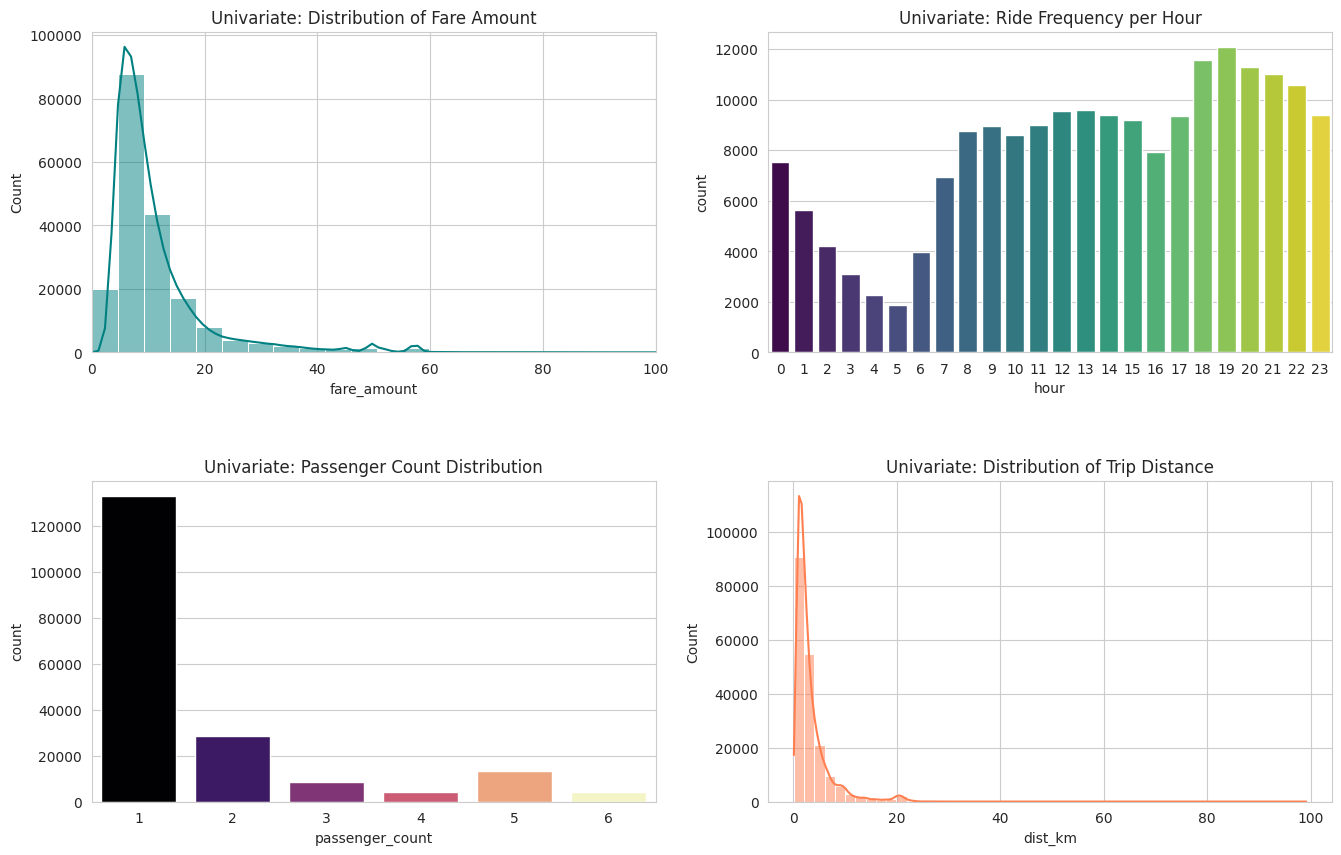

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
plt.subplots_adjust(hspace=0.4)

# 1. Fare Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['fare_amount'], bins=50, kde=True, color='teal')
plt.title('Univariate: Distribution of Fare Amount')
plt.xlim(0, 100)

# 2. Hourly Demand (Frequency of rides per hour)
plt.subplot(2, 2, 2)
sns.countplot(x='hour', data=df, hue='hour', palette='viridis', legend=False)
plt.title('Univariate: Ride Frequency per Hour')

# 3. Passenger Count Distribution
plt.subplot(2, 2, 3)
sns.countplot(x='passenger_count', data=df, hue='passenger_count', palette='magma', legend=False)
plt.title('Univariate: Passenger Count Distribution')

# 4. Trip Distance Distribution
plt.subplot(2, 2, 4)
sns.histplot(df['dist_km'], bins=50, kde=True, color='coral')
plt.title('Univariate: Distribution of Trip Distance')

plt.show()

bivariate

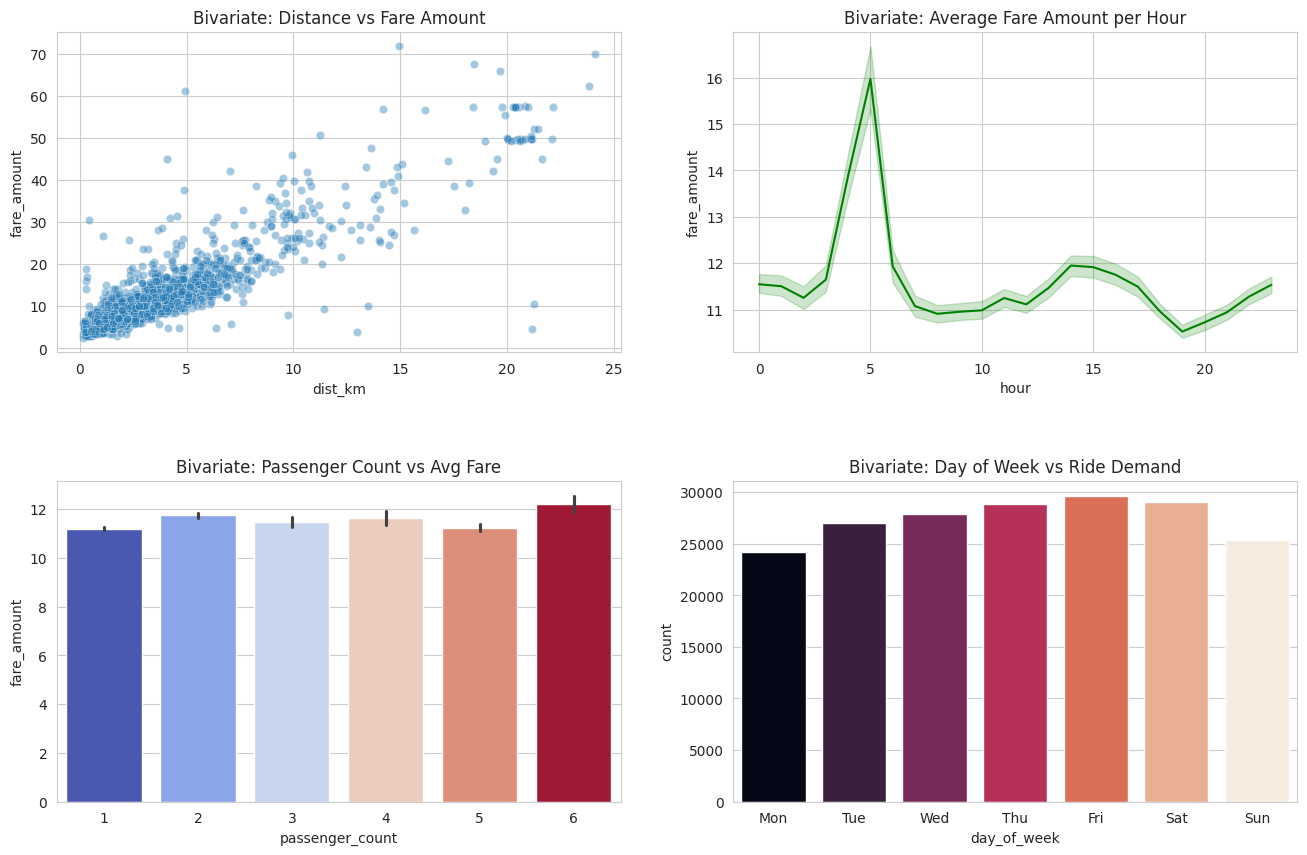

In [ ]:
plt.figure(figsize=(16, 10))
plt.subplots_adjust(hspace=0.4)

# 1. Distance vs Fare (The strongest relationship)
plt.subplot(2, 2, 1)
sns.scatterplot(x='dist_km', y='fare_amount', data=df.sample(2000), alpha=0.4)
plt.title('Bivariate: Distance vs Fare Amount')

# 2. Hour of Day vs Fare Amount (Checking for surge patterns)
plt.subplot(2, 2, 2)
sns.lineplot(x='hour', y='fare_amount', data=df, color='green')
plt.title('Bivariate: Average Fare Amount per Hour')

# 3. Passenger Count vs Fare Amount
plt.subplot(2, 2, 3)
sns.barplot(x='passenger_count', y='fare_amount', data=df, palette='coolwarm', hue='passenger_count', legend=False)
plt.title('Bivariate: Passenger Count vs Avg Fare')

# 4. Day of Week vs Number of Rides (Location vs Demand Trend)
plt.subplot(2, 2, 4)
sns.countplot(x='day_of_week', data=df, hue='day_of_week', palette='rocket', legend=False)
plt.title('Bivariate: Day of Week vs Ride Demand')
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.show()

demand forecast

Demand Forecast - R2 Score: 0.58
Demand Forecast - MAE: 3.75 rides


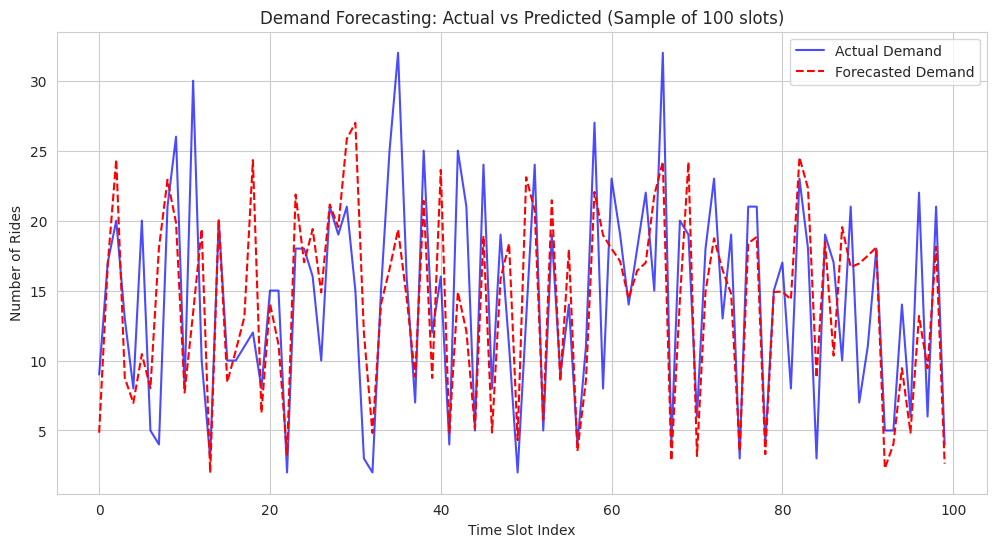

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare Data: Aggregate rides by Hour, Day, and Month
# This creates a "Ride Count" (the target we want to forecast)
demand_df = df.groupby(['year', 'month', 'day_of_week', 'hour']).size().reset_index(name='ride_count')

# 2. Define Features and Target
# We want to use the time components to predict the count
X = demand_df[['month', 'day_of_week', 'hour']]
y = demand_df['ride_count']

# 3. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Regressor
rf_demand = RandomForestRegressor(n_estimators=100, random_state=42)
rf_demand.fit(X_train, y_train)

# 5. Make Predictions
y_pred = rf_demand.predict(X_test)

# 6. Evaluate and Visualize
print(f"Demand Forecast - R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Demand Forecast - MAE: {mean_absolute_error(y_test, y_pred):.2f} rides")

# Comparison Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Demand', color='blue', alpha=0.7)
plt.plot(y_pred[:100], label='Forecasted Demand', color='red', linestyle='--')
plt.title('Demand Forecasting: Actual vs Predicted (Sample of 100 slots)')
plt.xlabel('Time Slot Index')
plt.ylabel('Number of Rides')
plt.legend()
plt.show()

fare prediction

Linear Regression RMSE: $5.10
Random Forest RMSE: $4.32


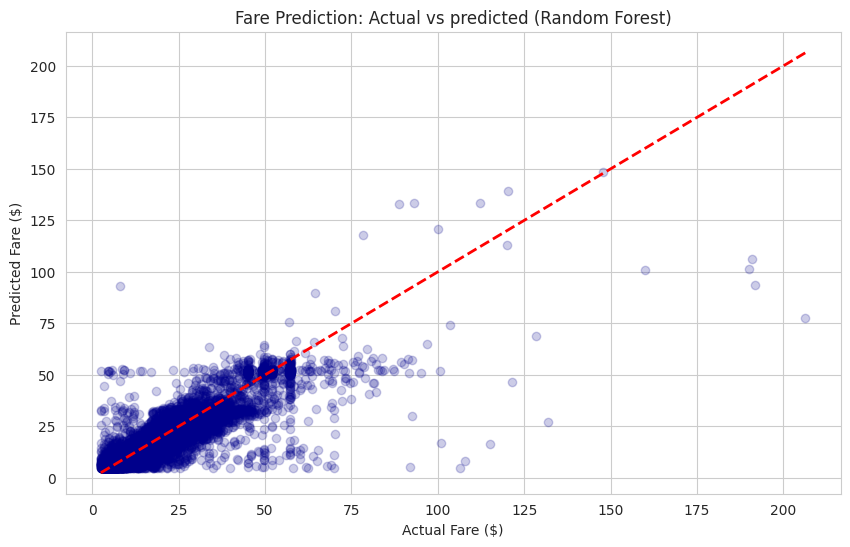

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Prepare Features
# We use distance, time, and passenger count to predict the fare_amount
features = ['dist_km', 'hour', 'day_of_week', 'passenger_count']
X_fare = df[features]
y_fare = df['fare_amount']

# 2. Split Data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fare, y_fare, test_size=0.2, random_state=42)

# 3. Model A: Linear Regression (Simple Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train_f, y_train_f)
lr_pred = lr_model.predict(X_test_f)

# 4. Model B: Random Forest (Captures non-linear traffic patterns)
rf_fare = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf_fare.fit(X_train_f, y_train_f)
rf_pred = rf_fare.predict(X_test_f)

# 5. Evaluation
print(f"Linear Regression RMSE: ${np.sqrt(mean_squared_error(y_test_f, lr_pred)):.2f}")
print(f"Random Forest RMSE: ${np.sqrt(mean_squared_error(y_test_f, rf_pred)):.2f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_f, rf_pred, alpha=0.2, color='darkblue')
plt.plot([y_test_f.min(), y_test_f.max()], [y_test_f.min(), y_test_f.max()], '--r', lw=2)
plt.title('Fare Prediction: Actual vs predicted (Random Forest)')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.show()

driver allocation

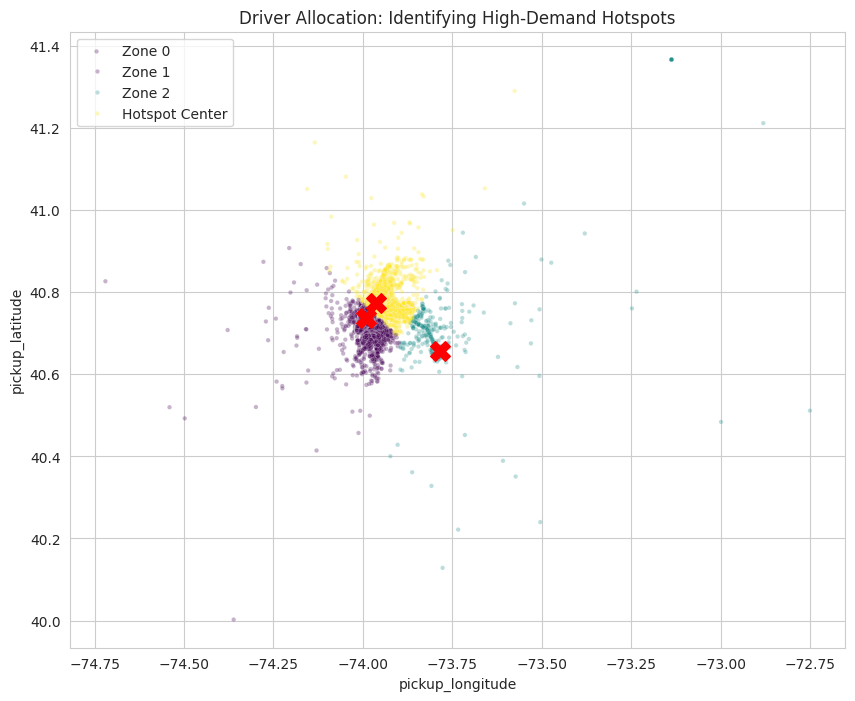

In [ ]:
from sklearn.cluster import KMeans

# 1. Prepare coordinate data
coords = df[['pickup_longitude', 'pickup_latitude']]

# 2. Apply K-Means
# We will create 3 clusters representing demand density
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['demand_cluster'] = kmeans.fit_predict(coords)

# 3. Map the Clusters
plt.figure(figsize=(10, 8))
# Plot each cluster with a different color
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', hue='demand_cluster',
                data=df, palette='viridis', s=10, alpha=0.3)

# Mark the center of each cluster (The "Hotspots")
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Hotspots')

plt.title('Driver Allocation: Identifying High-Demand Hotspots')
plt.legend(['Zone 0', 'Zone 1', 'Zone 2', 'Hotspot Center'])
plt.show()

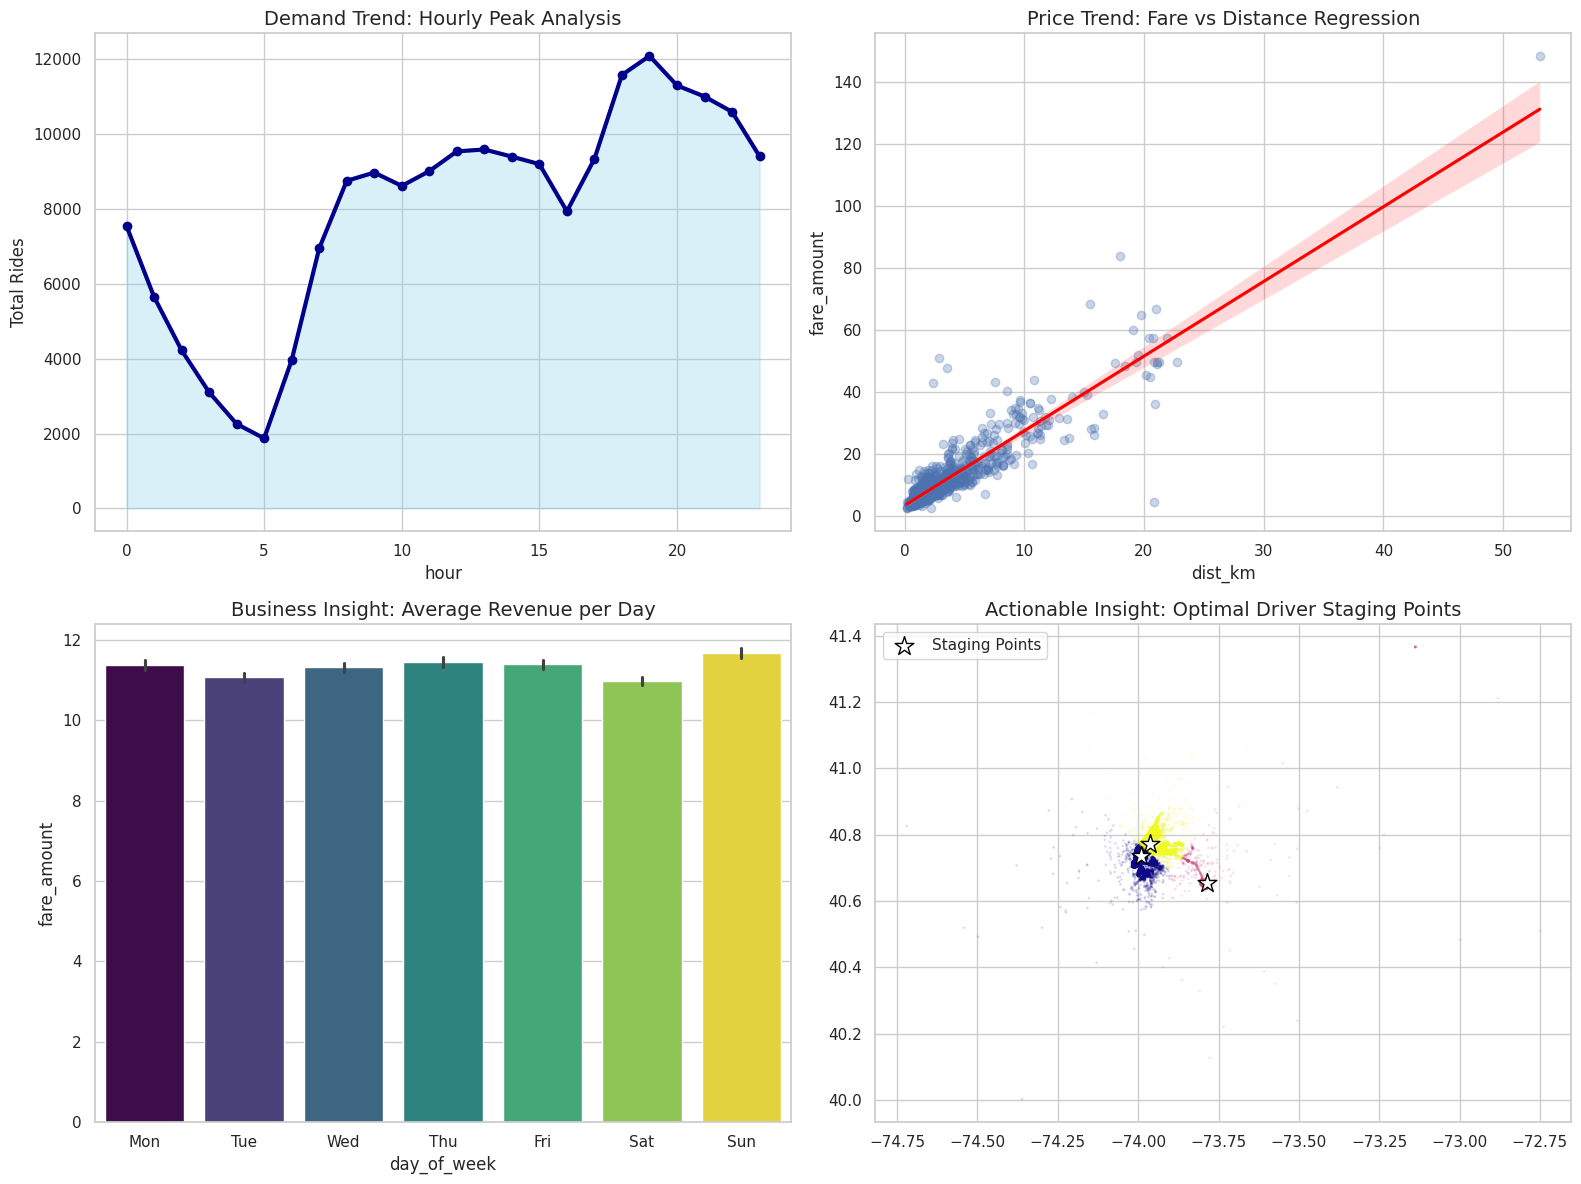

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional presentation
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. TREND: Peak Demand Hours (For Supply Management)
plt.subplot(2, 2, 1)
avg_demand = df.groupby('hour').size()
avg_demand.plot(kind='line', marker='o', color='darkblue', linewidth=3)
plt.fill_between(avg_demand.index, avg_demand.values, color='skyblue', alpha=0.3)
plt.title('Demand Trend: Hourly Peak Analysis', fontsize=14)
plt.ylabel('Total Rides')

# 2. TREND: Fare Sensitivity by Distance (For Pricing Strategy)
plt.subplot(2, 2, 2)
sns.regplot(x='dist_km', y='fare_amount', data=df.sample(1000),
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price Trend: Fare vs Distance Regression', fontsize=14)

# 3. INSIGHT: Efficiency by Day of Week (For Driver Scheduling)
plt.subplot(2, 2, 3)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x='day_of_week', y='fare_amount', data=df, palette='viridis', hue='day_of_week', legend=False)
plt.xticks(ticks=range(7), labels=day_labels)
plt.title('Business Insight: Average Revenue per Day', fontsize=14)

# 4. INSIGHT: Demand Hotspots (For Physical Allocation)
plt.subplot(2, 2, 4)
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], c=df['demand_cluster'], cmap='plasma', s=1, alpha=0.1)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='white', edgecolors='black', s=200, marker='*', label='Staging Points')
plt.title('Actionable Insight: Optimal Driver Staging Points', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()